# A tour of outlap

**outlap** is an open-source, parametric vehicle simulator: a car is *pure data* — a set of
YAML/CSV files — and one engine evaluates any of them, from an F1 hybrid to a road hatchback.
The core is Rust (fast, deterministic, WASM-clean); you drive it from Python.

This notebook walks every capability shipped so far, live:

1. **The car as data** — the input files, validation, and the loaded-model report
2. **The 3D track** — a real circuit imported from OpenStreetMap + elevation data
3. **The racing line** — a minimum-curvature quadratic program
4. **A lap** — the T0 point-mass solver: speed profile, g-g diagram, lap time
5. **The tyre model** — Magic Formula 6.1, the heart of the physics
6. **Trust, but verify** — the ≤0.5 % cross-check against an independent oracle

Run it yourself from the repo root:

```bash
cd python && uv sync --group notebooks     # builds the Rust core automatically
uv run --with jupyterlab jupyter lab ../notebooks/00_tour_of_outlap.ipynb
```

Every number here is computed on the spot by the Rust core through the `outlap.core` bindings —
nothing is hard-coded.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap

from outlap.core import (
    Track,
    Tyre,
    min_curvature,
    solve_lap_dataset,
    track_dataset,
    tyre_forces,
    vehicle_report,
)


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# --- chart style: the validated reference palette (light mode) -------------------------------
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"  # categorical slots 1, 2, 6
LOADS3 = ["#86b6ef", "#2a78d6", "#104281"]  # ordinal ramp: 3 ordered magnitudes
ALPHAS4 = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]  # ordinal ramp: 4 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "font.size": 10.5,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
    }
)

print(f"repo root found: …/{ROOT.name}")

repo root found: …/outlap


## 1 · The car as data

A vehicle is a directory of plain files — the **input quartet** is `vehicle.yaml` (the car) +
`track.yaml` (the road) + `conditions.yaml` (the session) + `sim.yaml` (the numerics). The car
never becomes code: chassis, aero, suspension, tyres and the powertrain topology are all data.
Here is the start of the bundled F1-2026-style reference car:

In [2]:
VEH = ROOT / "data" / "vehicles" / "f1_2026"
lines = (VEH / "vehicle.yaml").read_text().splitlines()
start = next(i for i, ln in enumerate(lines) if ln.startswith("schema:"))
print("\n".join(lines[start : start + 14]), "\n…")

schema: vehicle/1.0
name: "Reference F1 2026 hybrid"
chassis:
  mass_kg: 768.0
  cg: [1.70, 0.0, 0.30]
  inertia: [180.0, 950.0, 1000.0]
  wheelbase_m: 3.40
  track_m: [1.65, 1.60]
aero:
  map: aero/f1_2026.parquet
  axes: [ride_height_f_mm, ride_height_r_mm, yaw_deg, drs_flag]
  # SYNTHETIC constant-coefficient fallback (Locked Decision #15) — used by the T0 point-mass tier
  # until the ride-height aero map is consumed (T1). Physically-plausible high-downforce values:
  # total CzA 4.5 m² gives ~1.7x car-weight downforce at 250 km/h; L/D ~3.6. NOT measured data. 
…


Loading is a product surface, not an afterthought: every value the loader inherited from a
preset, **estimated** from a heuristic, or degraded is recorded in the *loaded-model report* —
nothing is silent. That report travels with every result (as a hash of the resolved spec), so a
lap time is always traceable to the exact car that produced it.

In [3]:
rep = vehicle_report(str(VEH))
print(f"{rep['name']}  ·  resolved-spec hash {str(rep['resolved_hash'])[:16]}…\n")
print(f"estimated values ({len(rep['estimated'])}):")
for pointer, detail in rep["estimated"]:
    print(f"  {pointer:42s} {detail}")
for bucket in ("degraded", "warnings"):
    entries = rep[bucket]
    print(f"{bucket}: {len(entries)}")

Reference F1 2026 hybrid  ·  resolved-spec hash 3962af2692b2b0a8…

estimated values (7):
  /suspension/front/anti_squat               assumed 0 (no anti-squat geometry)
  /suspension/front/camber_map               no camber map — assumed zero camber change with travel
  /suspension/front/toe_map                  no toe map — assumed zero toe change with travel
  /suspension/rear/anti_dive                 assumed 0 (no anti-dive geometry)
  /suspension/rear/camber_map                no camber map — assumed zero camber change with travel
  /suspension/rear/toe_map                   no toe map — assumed zero toe change with travel
  /ers/deployment/per_lap_deploy_mj          assumed = usable capacity (4 MJ)
degraded: 0
warnings: 0


## 2 · The 3D track

Tracks are imported from **OpenStreetMap** centerlines fused with open elevation models, then
fitted with a spline that answers position, curvature, grade and banking at any arc length `s`.
The bundled Circuit de Barcelona-Catalunya is real data — including its ~30 m of elevation
change, which the solver feels as normal-load variation. (Real data also means real noise:
the speckle in the curvature map below is GPS-grade centerline jitter. The solver smooths it
lightly, and the racing line in the next section removes it at the source.)

Circuit de Barcelona-Catalunya — 4678 m, closed loop


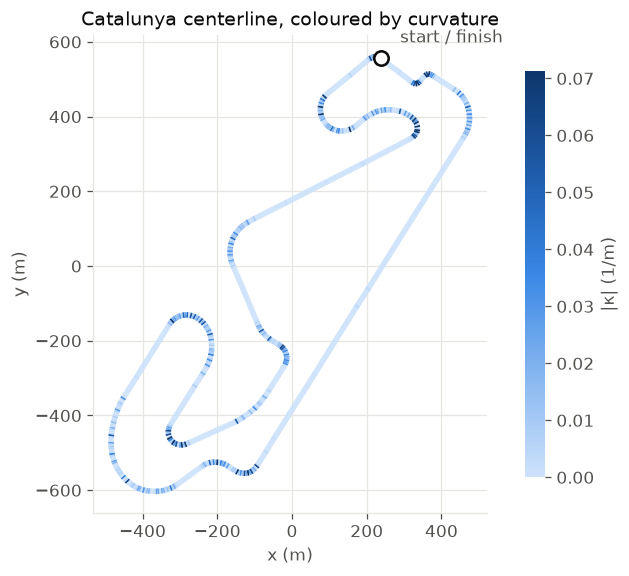

In [4]:
track = Track.load(str(ROOT / "data" / "tracks" / "catalunya"))
ds = track_dataset(track, ds_m=5.0)
print(f"{ds.attrs['name']} — {ds.attrs['length_m']:.0f} m, closed loop")

x, y = ds.x.to_numpy(), ds.y.to_numpy()
kappa = np.abs(ds.kappa_h.to_numpy())

pts = np.column_stack([x, y]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc = LineCollection(
    segs, cmap=SEQ, norm=mpl.colors.Normalize(0.0, np.quantile(kappa, 0.98))
)
lc.set_array(kappa[:-1])
lc.set_linewidth(3.5)

fig, ax = plt.subplots(figsize=(8.4, 5.4))
ax.add_collection(lc)
ax.plot(x[0], y[0], "o", ms=9, mfc="white", mec=INK, mew=1.6, zorder=5)
ax.annotate(
    "start / finish", (x[0], y[0]), xytext=(12, 10), textcoords="offset points", color=INK2
)
ax.set_aspect("equal")
ax.autoscale()
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Catalunya centerline, coloured by curvature")
cb = fig.colorbar(lc, ax=ax, shrink=0.85, label="|κ| (1/m)")
cb.outline.set_visible(False)
plt.show()

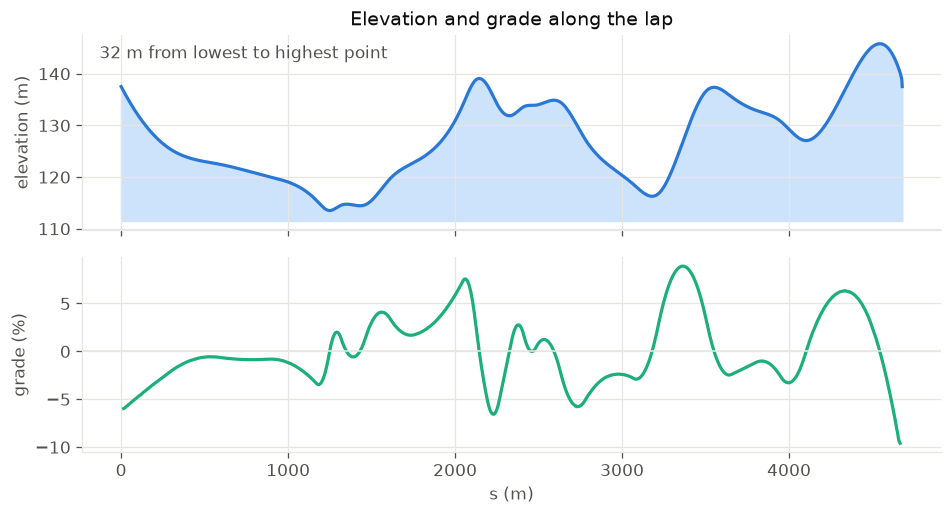

banking range: +0.00° … +0.00°  (not resolved from the elevation model for this import — carried as 0)


In [5]:
s, z = ds.s.to_numpy(), ds.z.to_numpy()
# The closed-loop seam of the imported centerline produces edge artifacts in the grade
# derivative; show the interior of the lap.
interior = slice(3, -3)
grade_pct = 100.0 * np.tan(ds.grade.to_numpy())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.4, 4.6), sharex=True)
ax1.fill_between(s, z, z.min() - 2, color="#cde2fb")
ax1.plot(s, z, color=BLUE)
ax1.set_ylabel("elevation (m)")
ax1.set_title("Elevation and grade along the lap")
ax2.plot(s[interior], grade_pct[interior], color=AQUA)
ax2.axhline(0, color=GRID, lw=1)
ax2.set_ylabel("grade (%)")
ax2.set_xlabel("s (m)")
climb = z.max() - z.min()
ax1.text(0.02, 0.88, f"{climb:.0f} m from lowest to highest point",
         transform=ax1.transAxes, color=INK2)
plt.tight_layout()
plt.show()

print(f"banking range: {np.degrees(ds.banking.to_numpy()).min():+.2f}° … "
      f"{np.degrees(ds.banking.to_numpy()).max():+.2f}°  "
      "(not resolved from the elevation model for this import — carried as 0)")

## 3 · The racing line

The centerline is where a surveyor drives, not a racer. outlap generates a
**minimum-curvature line** by solving a quadratic program over the lateral offset `n(s)` inside
the track corridor (car half-width + margin as the bounds). Minimum curvature ≈ maximum
cornering speed for a grip-limited car — and the result is itself a first-class track the
solver can lap.

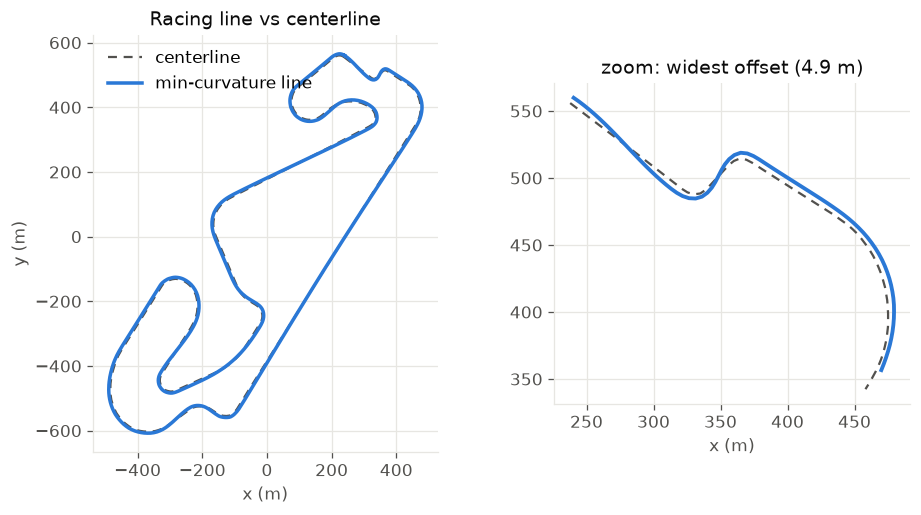

In [6]:
rl = min_curvature(track, half_width_m=1.1)
line_ds = track_dataset(rl.line(), ds_m=5.0)
lx, ly = line_ds.x.to_numpy(), line_ds.y.to_numpy()
n = rl.n()

fig, (ax, axz) = plt.subplots(
    1, 2, figsize=(8.6, 4.6), gridspec_kw={"width_ratios": [1.5, 1.0]}
)
ax.plot(x, y, color=INK2, lw=1.4, ls=(0, (4, 3)), label="centerline")
ax.plot(lx, ly, color=BLUE, lw=2.2, label="min-curvature line")
ax.set_aspect("equal")
ax.set_title("Racing line vs centerline")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(loc="upper left")

# zoom on the corner where the line moves furthest off centre
s_line = rl.s()
i_max = int(np.argmax(np.abs(n)))
s0 = s_line[i_max]
win = (ds.s.to_numpy() > s0 - 220) & (ds.s.to_numpy() < s0 + 220)
winl = (line_ds.s.to_numpy() > s0 - 220) & (line_ds.s.to_numpy() < s0 + 220)
axz.plot(x[win], y[win], color=INK2, lw=1.4, ls=(0, (4, 3)))
axz.plot(lx[winl], ly[winl], color=BLUE, lw=2.4)
axz.set_aspect("equal")
axz.set_title(f"zoom: widest offset ({np.abs(n).max():.1f} m)")
axz.set_xlabel("x (m)")
plt.tight_layout()
plt.show()

How much is that worth? Solve the same car on both lines and integrate the time difference:

centerline lap    104.733 s
racing-line lap   100.708 s
gain                4.025 s


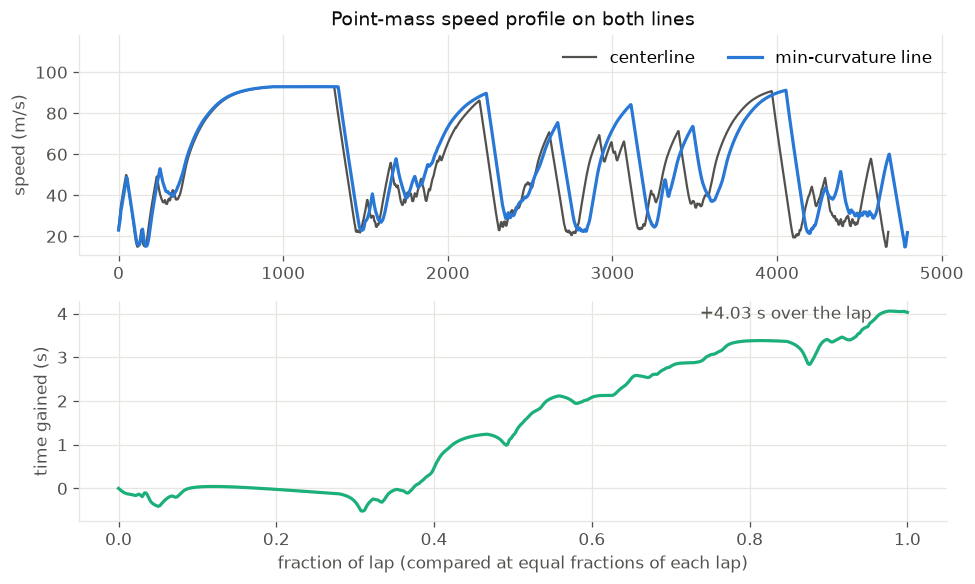

In [7]:
lap_c = solve_lap_dataset(str(VEH), track)
lap_r = solve_lap_dataset(str(VEH), rl)
gain = lap_c.attrs["lap_time_s"] - lap_r.attrs["lap_time_s"]
print(f"centerline lap    {lap_c.attrs['lap_time_s']:7.3f} s")
print(f"racing-line lap   {lap_r.attrs['lap_time_s']:7.3f} s")
print(f"gain              {gain:7.3f} s")

sc, vc = lap_c.s.to_numpy(), lap_c.v.to_numpy()
sr, vr = lap_r.s.to_numpy(), lap_r.v.to_numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.6, 5.2), sharex=False)
ax1.plot(sc, vc, color=INK2, lw=1.4, label="centerline")
ax1.plot(sr, vr, color=BLUE, lw=2.0, label="min-curvature line")
ax1.set_ylabel("speed (m/s)")
ax1.set_title("Point-mass speed profile on both lines")
ax1.set_ylim(top=ax1.get_ylim()[1] * 1.22)  # headroom so the legend never sits on the traces
ax1.legend(loc="upper right", ncols=2)

# cumulative time gained. The two laps have different lengths (the racing line is a
# different path), so they are compared at equal FRACTIONS of each lap — exact at the
# start/finish, approximate mid-lap.
assert gain > 0, "the racing line should beat the centerline"
frac = sc / sc[-1]
tc = lap_c.t.to_numpy()
tr = np.interp(frac, sr / sr[-1], lap_r.t.to_numpy())
ax2.plot(frac, tc - tr, color=AQUA)
ax2.set_xlabel("fraction of lap (compared at equal fractions of each lap)")
ax2.set_ylabel("time gained (s)")
ax2.annotate(f"{gain:+.2f} s over the lap", (frac[-1], (tc - tr)[-1]),
             xytext=(-130, -4), textcoords="offset points", color=INK2)
plt.tight_layout()
plt.show()

## 4 · A lap, dissected

T0 is the first solver tier: a **point-mass with a friction ellipse** on the 3D ribbon —
curvature-limited speed per station, then forward (traction-limited) and backward
(braking-limited) passes. Simple, allocation-free, and deterministic: the same inputs give the
same lap, run after run.

The classic way to see a lap: the **g-g diagram** — every station plotted by its lateral and
longitudinal acceleration. A point-mass car fills an ellipse; the engine caps the top
(traction-limited) side.

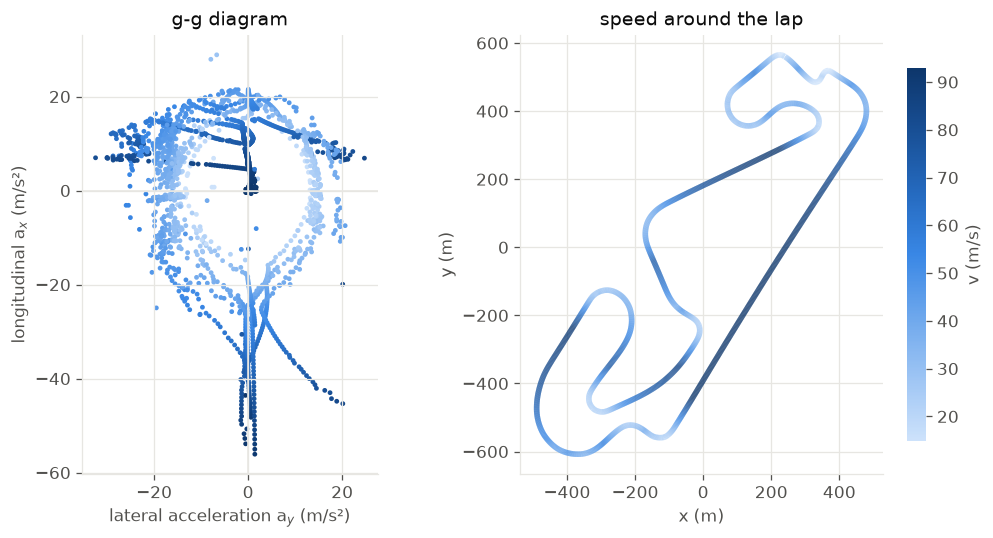

lap time 100.708 s · top speed 93.0 m/s (335 km/h)
solver notes (nothing silent):
  - ERS modelled as a power cap; per-lap deploy/harvest budgets and override mode are not enforced at T0
  - μ derived from MF6.1 pure-slip peak @ FNOMIN, p_cold (mean of front/rear); braking is friction-limited only at T0


In [8]:
lap = lap_r  # the racing-line lap from above
ax_a, ay_a, v_a = lap.ax.to_numpy(), lap.ay.to_numpy(), lap.v.to_numpy()

fig, (axg, axm) = plt.subplots(
    1, 2, figsize=(9.0, 4.8), gridspec_kw={"width_ratios": [1.0, 1.35]}
)
sc_pts = axg.scatter(ay_a, ax_a, c=v_a, cmap=SEQ, s=9, lw=0)
axg.axhline(0, color=GRID, lw=1)
axg.axvline(0, color=GRID, lw=1)
axg.set_xlabel("lateral acceleration a$_y$ (m/s²)")
axg.set_ylabel("longitudinal a$_x$ (m/s²)")
axg.set_title("g-g diagram")
axg.set_aspect("equal")

lpts = np.column_stack([lap.x.to_numpy(), lap.y.to_numpy()]).reshape(-1, 1, 2)
lsegs = np.concatenate([lpts[:-1], lpts[1:]], axis=1)
lcv = LineCollection(lsegs, cmap=SEQ)
lcv.set_array(v_a[:-1])
lcv.set_linewidth(3.5)
axm.add_collection(lcv)
axm.set_aspect("equal")
axm.autoscale()
axm.set_title("speed around the lap")
axm.set_xlabel("x (m)")
axm.set_ylabel("y (m)")
cb = fig.colorbar(lcv, ax=axm, shrink=0.85, label="v (m/s)")
cb.outline.set_visible(False)
plt.tight_layout()
plt.show()

print(f"lap time {lap.attrs['lap_time_s']:.3f} s · top speed {v_a.max():.1f} m/s "
      f"({v_a.max() * 3.6:.0f} km/h)")
print("solver notes (nothing silent):")
for note in lap.attrs["notes"]:
    print("  -", note)

## 5 · The tyre — Magic Formula 6.1

Everything a car does goes through four contact patches, so the tyre model is the heart of the
simulator. outlap implements **Pacejka's Magic Formula 6.1** — the industry-standard
steady-state model — clean-room from the book, validated against an independent oracle (next
section), and consumed from the same `.tyr` file by every solver tier. (The point-mass T0
reduces it to a pair of constant peak μ values, read off these very curves at nominal load and cold pressure — that's what its solver notes above disclose; the full
curves you see here drive the higher tiers.)

This is the book's own reference tyre: a 205/60R15 passenger car tyre, transcribed from
Pacejka (2006), Table A3.1.

In [9]:
tyre = Tyre.load(str(ROOT / "data" / "tires" / "pacejka_2006_205_60r15" / "car.tyr.yaml"))
print(tyre.citation)
mux, muy = tyre.peak_mu(tyre.fnomin, tyre.p_cold)
print(f"nominal load {tyre.fnomin:.0f} N · R0 {tyre.unloaded_radius:.3f} m · "
      f"peak μx {mux:.2f} · peak μy {muy:.2f}")

H. B. Pacejka, Tyre and Vehicle Dynamics, 2nd ed. (2006), Appendix 3, Table A3.1 (205/60R15 91V, 2.2 bar, ISO sign)
nominal load 4000 N · R0 0.313 m · peak μx 1.21 · peak μy 1.03


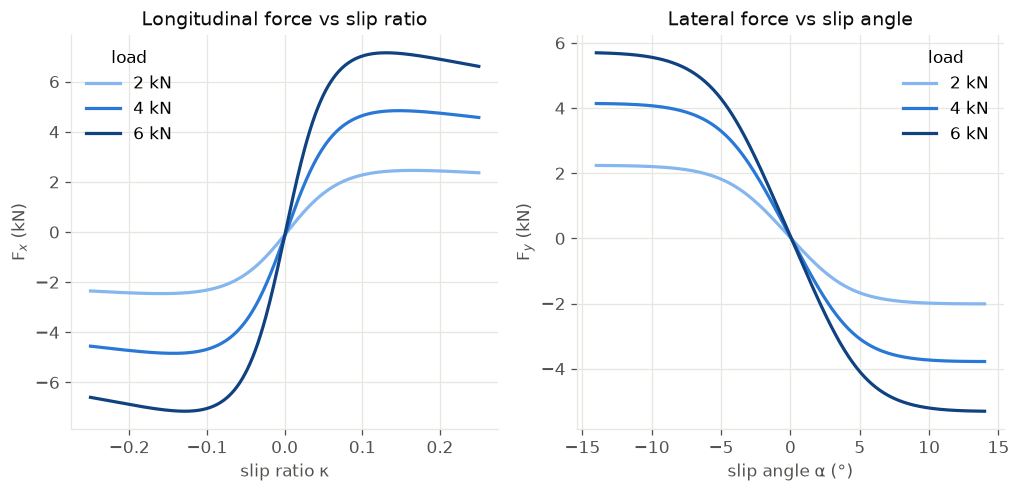

In [10]:
kappa = np.linspace(-0.25, 0.25, 300)
alpha = np.linspace(np.radians(-14), np.radians(14), 300)
loads = [2000.0, 4000.0, 6000.0]

fig, (axx, axy) = plt.subplots(1, 2, figsize=(9.0, 4.4), sharey=False)
for fz, c in zip(loads, LOADS3):
    fx = tyre_forces(tyre, kappa=kappa, fz=fz).fx
    axx.plot(kappa, fx / 1000, color=c, label=f"{fz / 1000:.0f} kN")
    fy = tyre_forces(tyre, alpha=alpha, fz=fz).fy
    axy.plot(np.degrees(alpha), fy / 1000, color=c, label=f"{fz / 1000:.0f} kN")

axx.set_xlabel("slip ratio κ")
axx.set_ylabel("F$_x$ (kN)")
axx.set_title("Longitudinal force vs slip ratio")
axx.legend(title="load")
axy.set_xlabel("slip angle α (°)")
axy.set_ylabel("F$_y$ (kN)")
axy.set_title("Lateral force vs slip angle")
axy.legend(title="load")
plt.tight_layout()
plt.show()

Two signatures of a real tyre, both visible above:

- **The peak, then the fall.** Grip rises to a peak at a few percent slip / a few degrees of
  slip angle, then *decreases* — driving past the peak is how you overheat and lose time.
- **Load sensitivity.** Doubling the load does *not* double the force: the effective friction
  coefficient falls as load rises. This is why load transfer matters and why downforce is so
  valuable — it adds load without adding mass.

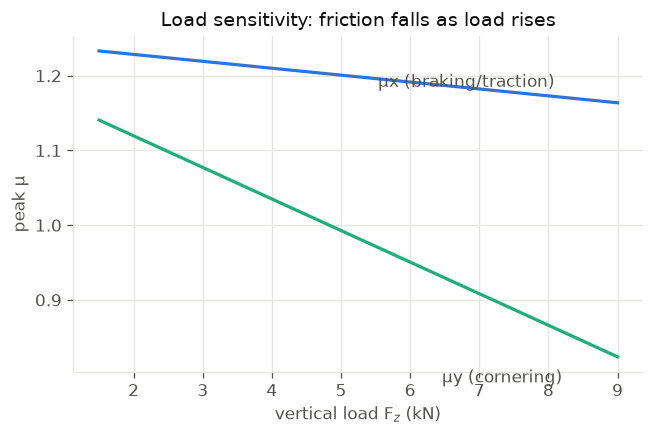

In [11]:
fzs = np.linspace(1500, 9000, 40)
mus = np.array([tyre.peak_mu(f, tyre.p_cold) for f in fzs])

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(fzs / 1000, mus[:, 0], color=BLUE)
ax.plot(fzs / 1000, mus[:, 1], color=AQUA)
ax.annotate("μx (braking/traction)", (fzs[-1] / 1000, mus[-1, 0]),
            xytext=(-150, 10), textcoords="offset points", color=INK2)
ax.annotate("μy (cornering)", (fzs[-1] / 1000, mus[-1, 1]),
            xytext=(-110, -16), textcoords="offset points", color=INK2)
ax.set_xlabel("vertical load F$_z$ (kN)")
ax.set_ylabel("peak μ")
ax.set_title("Load sensitivity: friction falls as load rises")
plt.show()

**Camber** leans the tyre into the road (`γ > 0` = top leaning left, toward +y). It generates a
small lateral force of its own (*camber thrust*) and shifts the whole slip curve — one of the
knobs suspension geometry tunes. And under **combined slip** — braking while cornering — the
tyre cannot give you full force in both directions at once: the operating points live inside a
*friction ellipse*.

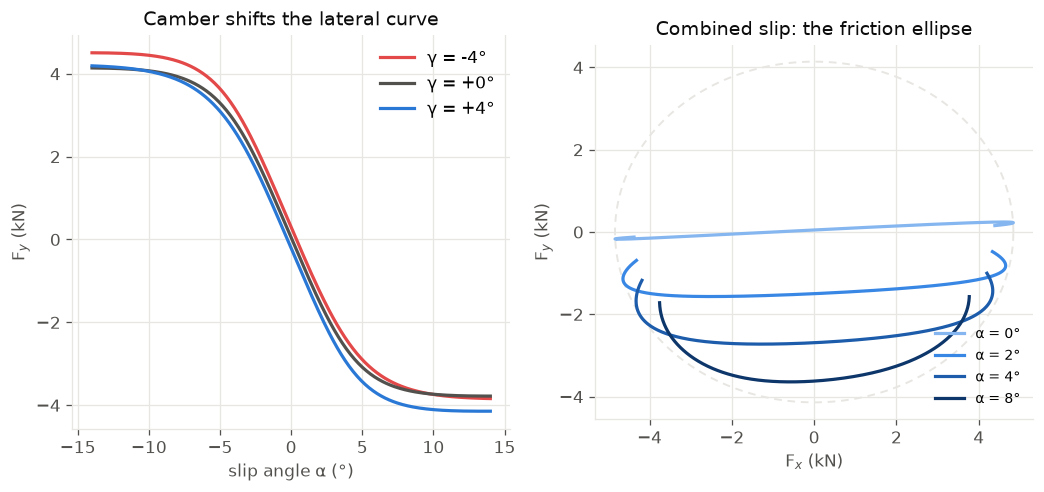

In [12]:
fig, (axc, axe) = plt.subplots(1, 2, figsize=(9.2, 4.4))

# camber sweep: diverging encoding (red = -4°, neutral ink = 0°, blue = +4°)
for gamma_deg, c in [(-4.0, RED), (0.0, INK2), (4.0, BLUE)]:
    fy = tyre_forces(tyre, alpha=alpha, gamma=np.radians(gamma_deg)).fy
    axc.plot(np.degrees(alpha), fy / 1000, color=c, label=f"γ = {gamma_deg:+.0f}°")
axc.set_xlabel("slip angle α (°)")
axc.set_ylabel("F$_y$ (kN)")
axc.set_title("Camber shifts the lateral curve")
axc.legend()

# combined slip: kappa sweeps at fixed slip angles → loci inside the friction circle
mu_x, mu_y = tyre.peak_mu(4000.0, tyre.p_cold)
th = np.linspace(0, 2 * np.pi, 200)
axe.plot(4.0 * mu_x * np.cos(th), 4.0 * mu_y * np.sin(th),
         color=GRID, lw=1.2, ls=(0, (4, 3)))
kk = np.linspace(-0.3, 0.3, 400)
for a_deg, c in zip([0.0, 2.0, 4.0, 8.0], ALPHAS4):
    f = tyre_forces(tyre, kappa=kk, alpha=np.radians(a_deg), fz=4000.0)
    axe.plot(f.fx / 1000, f.fy / 1000, color=c, label=f"α = {a_deg:.0f}°")
axe.set_xlabel("F$_x$ (kN)")
axe.set_ylabel("F$_y$ (kN)")
axe.set_title("Combined slip: the friction ellipse")
axe.set_aspect("equal")
axe.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

The tyre also produces a **self-aligning moment** M$_z$ — the torque that centres your steering
wheel. It comes from the lateral force acting behind the contact-patch centre (the *pneumatic
trail*). Note how it peaks *before* the lateral force does and collapses toward zero near the
grip limit: the steering goes light just as the front axle lets go. Drivers feel this model.

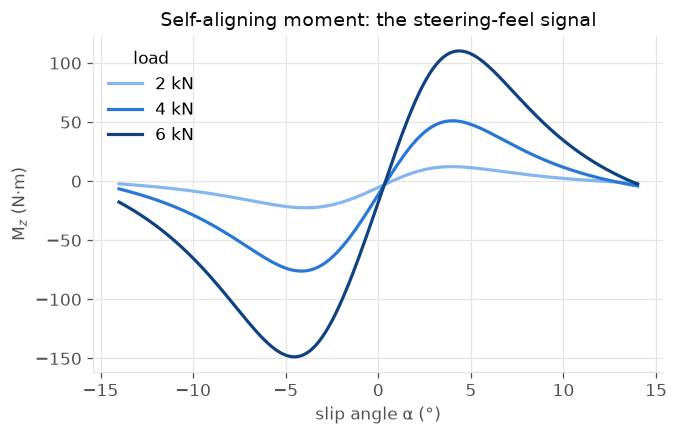

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for fz, c in zip(loads, LOADS3):
    mz = tyre_forces(tyre, alpha=alpha, fz=fz).mz
    ax.plot(np.degrees(alpha), mz, color=c, label=f"{fz / 1000:.0f} kN")
ax.set_xlabel("slip angle α (°)")
ax.set_ylabel("M$_z$ (N·m)")
ax.set_title("Self-aligning moment: the steering-feel signal")
ax.legend(title="load")
plt.show()

## 6 · Trust, but verify

A physics engine you can't check is a random-number generator with good marketing. The MF6.1
implementation is **clean-room from the book**, and its outputs are gated in CI to agree with an
independent Magic-Formula implementation (run once, offline, as a numerical oracle) to
**≤ 0.5 %** on every channel over slip, load, camber and combined-slip sweeps (Mx — identically
zero for this tyre — as a null check). The committed
golden CSVs carry their full provenance (oracle commit, Octave version) in their headers.

Here is that comparison, reproduced live — our model against the committed oracle points:

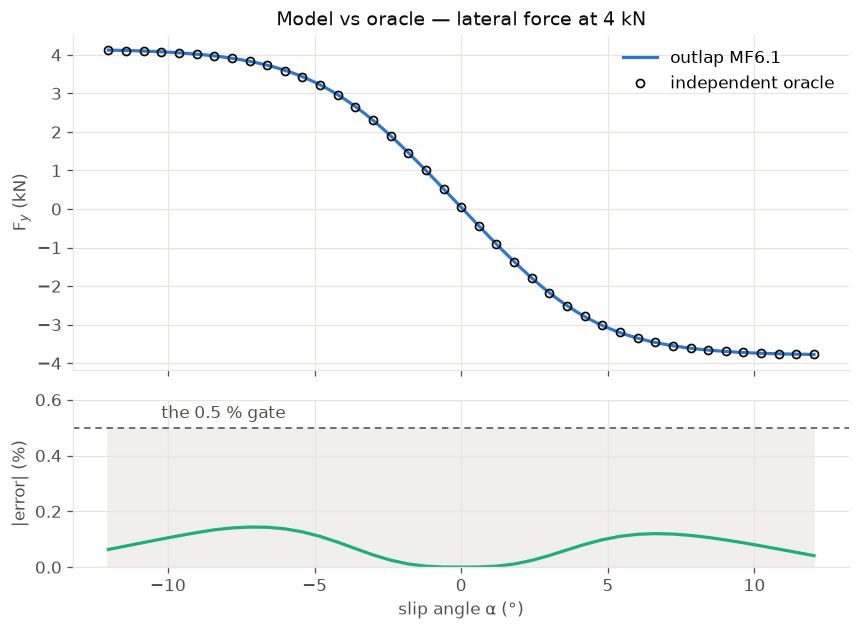

worst-case error on this slice: 0.144 %  (CI gate: 0.5 %)


In [14]:
import io

golden_path = (ROOT / "crates" / "outlap-tire" / "tests" / "golden"
               / "pacejka_2006_205_60r15" / "fy0_mz.csv")
golden_lines = [ln for ln in golden_path.read_text().splitlines() if not ln.startswith("#")]
golden = np.genfromtxt(io.StringIO("\n".join(golden_lines)), delimiter=",", names=True)
sel = (golden["fz_n"] == 4000.0) & (golden["gamma_rad"] == 0.0)
g = golden[sel]

a_fine = np.linspace(g["alpha_rad"].min(), g["alpha_rad"].max(), 400)
ours = tyre_forces(tyre, alpha=a_fine, fz=4000.0, p=220e3, vx=16.67)
ours_at = tyre_forces(tyre, alpha=g["alpha_rad"], fz=4000.0, p=220e3, vx=16.67)

fig, (axf, axe) = plt.subplots(
    2, 1, figsize=(7.6, 5.6), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]}
)
axf.plot(np.degrees(a_fine), ours.fy / 1000, color=BLUE, label="outlap MF6.1")
axf.plot(np.degrees(g["alpha_rad"]), g["fy_n"] / 1000, "o", ms=5,
         mfc="none", mec=INK, mew=1.1, ls="none", label="independent oracle")
axf.set_ylabel("F$_y$ (kN)")
axf.set_title("Model vs oracle — lateral force at 4 kN")
axf.legend()

# Same rule as the CI gate (crates/outlap-tire/tests/golden.rs): percent error with the
# denominator floored at |PDY1|·Fz so the zero-crossing does not divide by ~0.
rel = 100.0 * np.abs(ours_at.fy - g["fy_n"]) / np.maximum(np.abs(g["fy_n"]), 0.99 * 4000.0)
assert rel.max() <= 0.5, "the 0.5% gate must hold"
axe.fill_between(np.degrees(g["alpha_rad"]), 0, 0.5, color="#f0efec")
axe.plot(np.degrees(g["alpha_rad"]), rel, color=AQUA)
axe.axhline(0.5, color=INK2, lw=1, ls=(0, (4, 3)))
axe.set_ylim(0, 0.6)
axe.set_xlabel("slip angle α (°)")
axe.set_ylabel("|error| (%)")
axe.annotate("the 0.5 % gate", (np.degrees(g['alpha_rad'])[3], 0.5),
             xytext=(0, 6), textcoords="offset points", color=INK2)
plt.tight_layout()
plt.show()
print(f"worst-case error on this slice: {rel.max():.3f} %  (CI gate: 0.5 %)")

## Where to next

- **Theory pages** — every model ships with its equations and citations in the same PR:
  [`docs/theory/`](../docs/theory/) (T0 solver, MF6.1 steady state).
- **Reference data** — the tyres in [`data/tires/`](../data/tires/) and tracks in
  [`data/tracks/`](../data/tracks/) each carry a README with full provenance.
- **The oracle harness** — how the golden CSVs are generated and governed:
  [`tools/goldens/`](../tools/goldens/).
- **Bring your own car** — copy `data/vehicles/f1_2026/`, edit the YAML, and point
  `solve_lap_dataset` at it. Validation errors come back with line-and-column spans and
  did-you-mean suggestions.

Coming next in the milestone plan: the brush tyre tier and relaxation transients, the `.tir`
interchange format, a scipy fitting pipeline for members with test data, and deep-dive
notebooks for each subsystem.